# 1D spin-1 XY cages

This notebook mirrors the QLM cage workflow, but uses the 1D spin-1 XY chain. Instead of drawing basis states, it renders basis configurations as `pandas.DataFrame` objects.

Workflow:

1. Build a small spin-1 XY chain Hamiltonian.
2. Search for interference-caged states.
3. Select one cage record.
4. Classify the cage using the zero-mechanism report.
5. Render the cage support and nontrivial interference-zero basis states as tables.

## Imports

Keep imports centralized so the rest of the notebook reads as the actual workflow.

In [34]:
from __future__ import annotations

import numpy as np
import pandas as pd
from IPython.display import display

from qlinks.caging import (
    CageClassificationConfig,
    CageSearchConfig,
    CageSearcher,
    classify_cage_state,
)
from qlinks.models import SpinOneXYChainModel
from qlinks.visualizer import (
    HamiltonianGraphStyle,
    HamiltonianGraphVisualizer,
)

## Small table helpers

These helpers replace the plotting utilities used in the 2D QLM notebook. The important tables are:

- the full basis, optionally truncated;
- the support of a selected cage record;
- the nontrivial interference zeros, optionally split by mechanism.

In [2]:
def basis_configs_from_build_result(build_result):
    """Return the dense basis-configuration array from a model build result."""
    basis = build_result.basis

    if hasattr(basis, "states"):
        return np.asarray(basis.states)

    if hasattr(basis, "to_array_basis"):
        return np.asarray(basis.to_array_basis().states)

    raise TypeError(
        "Cannot infer basis configurations from build_result.basis. "
        "Expected .states or .to_array_basis().states."
    )


def kinetic_from_build_result(build_result):
    """Return the kinetic matrix from a build result, with small fallbacks."""
    kinetic = getattr(build_result, "kinetic", None)
    if kinetic is not None:
        return kinetic

    kinetic_term = getattr(build_result, "kinetic_term", None)
    if kinetic_term is not None:
        matrix = getattr(kinetic_term, "matrix", None)
        if matrix is not None:
            return matrix

    terms = getattr(build_result, "terms", None)
    if isinstance(terms, dict) and "kinetic" in terms:
        term = terms["kinetic"]
        return getattr(term, "matrix", term)

    H = getattr(build_result, "H", None)
    if H is not None:
        return H

    raise TypeError("Cannot infer the kinetic matrix from this build result.")


def hamiltonian_from_build_result(build_result):
    H = getattr(build_result, "H", None)
    if H is not None:
        return H
    hamiltonian = getattr(build_result, "hamiltonian", None)
    if hamiltonian is not None:
        return hamiltonian
    return kinetic_from_build_result(build_result)

In [3]:
def basis_dataframe(
    basis_configs,
    *,
    indices=None,
    amplitudes=None,
    amplitude_digits: int = 6,
    column_prefix: str = "site",
):
    """Render selected basis configurations as a DataFrame.

    Spin-1 local values are shown directly in the site columns. For the
    SpinOneXYChainModel these values should be m_i in {-1, 0, +1}.
    """
    basis_configs = np.asarray(basis_configs)

    if indices is None:
        indices = np.arange(basis_configs.shape[0], dtype=np.int64)
    else:
        indices = np.asarray(indices, dtype=np.int64)

    data = basis_configs[indices]
    columns = [f"{column_prefix}_{site}" for site in range(data.shape[1])]

    df = pd.DataFrame(data, columns=columns)
    df.insert(0, "basis_index", indices)

    if amplitudes is not None:
        amplitudes = np.asarray(amplitudes, dtype=np.complex128)
        if amplitudes.shape[0] != indices.shape[0]:
            raise ValueError("amplitudes and indices must have the same length.")

        df.insert(1, "amplitude", amplitudes)
        df.insert(2, "abs_amplitude", np.abs(amplitudes))
        df.insert(3, "phase_over_pi", np.angle(amplitudes) / np.pi)
        df["abs_amplitude"] = df["abs_amplitude"].round(amplitude_digits)
        df["phase_over_pi"] = df["phase_over_pi"].round(amplitude_digits)

    return df


def display_basis_dataframe(
    basis_configs,
    *,
    indices=None,
    amplitudes=None,
    max_rows: int = 64,
    title: str | None = None,
):
    df = basis_dataframe(
        basis_configs,
        indices=indices,
        amplitudes=amplitudes,
    )

    if title is not None:
        display(pd.DataFrame({"section": [title], "n_rows": [len(df)]}))

    with pd.option_context(
        "display.max_rows", max_rows,
        "display.max_columns", None,
        "display.width", 160,
    ):
        display(df.head(max_rows))

    return df

In [4]:
def select_cage_record(search_result, *, signature=None, record_index: int = 0):
    """Select a cage record from a CageSearchResult."""
    if signature is None:
        return search_result[record_index]
    return search_result[signature, record_index]


def search_summary_dataframe(search_result):
    """Summarize cage counts by signature."""
    rows = []

    if hasattr(search_result, "counts_by_signature"):
        counts_by_signature = search_result.counts_by_signature
    else:
        counts_by_signature = {
            signature: len(search_result[signature])
            for signature in getattr(search_result, "signatures", [])
        }

    for signature, count in counts_by_signature.items():
        rows.append({"signature": signature, "count": int(count)})

    return pd.DataFrame(rows)


def cage_support_dataframe(search_result, basis_configs, *, signature=None, record_index: int = 0):
    """Return the support states of one cage as a DataFrame."""
    record = select_cage_record(
        search_result,
        signature=signature,
        record_index=record_index,
    )

    return basis_dataframe(
        basis_configs,
        indices=np.asarray(record.support, dtype=np.int64),
        amplitudes=np.asarray(record.local_state, dtype=np.complex128),
    )

In [5]:
ZERO_MECHANISM_FIELDS = {
    "all": None,
    "q_empty": "q_empty_zero_indices",
    "closed_by_known_zeros": "closed_by_known_zero_indices",
    "projector_like": "projector_like_zero_indices",
    "unexplained_leakage": "unexplained_leakage_zero_indices",
    "regional": "regional_mechanism_zero_indices",
    "extended": "extended_mechanism_zero_indices",
    "failure": "failure_mechanism_zero_indices",
}


def zero_indices_from_report(classification_report, *, mechanism: str = "all"):
    """Return nontrivial-zero basis indices, optionally split by mechanism."""
    if mechanism not in ZERO_MECHANISM_FIELDS:
        allowed = ", ".join(ZERO_MECHANISM_FIELDS)
        raise ValueError(f"Unknown mechanism {mechanism!r}. Expected one of: {allowed}.")

    field = ZERO_MECHANISM_FIELDS[mechanism]
    if field is None:
        return np.array(
            [int(zero.zero_index) for zero in classification_report.zero_reports],
            dtype=np.int64,
        )

    return np.asarray(getattr(classification_report, field), dtype=np.int64)


def zero_mechanism_map(classification_report):
    """Map zero basis index to zero-mechanism label."""
    return {
        int(zero.zero_index): str(zero.mechanism_label)
        for zero in classification_report.zero_reports
    }


def interference_zero_dataframe(classification_report, basis_configs, *, mechanism: str = "all"):
    """Return nontrivial interference-zero states as a DataFrame."""
    indices = zero_indices_from_report(classification_report, mechanism=mechanism)
    mechanism_by_index = zero_mechanism_map(classification_report)

    df = basis_dataframe(basis_configs, indices=indices)
    df.insert(1, "mechanism", [mechanism_by_index.get(int(index), "unknown") for index in indices])
    return df


def mechanism_summary_dataframe(classification_report):
    """Summarize zero-level mechanisms in the classification report."""
    return pd.DataFrame(
        [
            {"mechanism_group": "regional", "mechanism": "q_empty", "count": classification_report.n_q_empty_zeros},
            {"mechanism_group": "regional", "mechanism": "closed_by_known_zeros", "count": classification_report.n_closed_by_known_zero_zeros},
            {"mechanism_group": "extended", "mechanism": "projector_like", "count": classification_report.n_projector_like_zeros},
            {"mechanism_group": "failure", "mechanism": "unexplained_leakage", "count": classification_report.n_unexplained_leakage_zeros},
        ]
    )

## Model and search parameters

The spin-1 XY model has local states `m_i in {-1, 0, +1}`, no constraints, and currently only supports `builder='sparse'`. Keep `length` modest because the full Hilbert space has size `3**length`.

In [20]:
length = 6
boundary_condition = "open"
j_xy, h_z, d_z = (1.0, 2.0, 1.0)


builder = "sparse"
basis_solver = "dfs"
sort_basis = False

search_config = CageSearchConfig(
    search_type="type1",
    tolerance=1e-10,
    validate_full_residual=True,
    degenerate_basis_strategy="ipr",
    ipr_n_restarts=128,
    ipr_candidate_count=64,
    ipr_random_seed=0,
)

classification_config = CageClassificationConfig(
    amplitude_tolerance=1e-10,
    cancellation_tolerance=1e-9,
    action_tolerance=1e-9,
)

## Build the Hamiltonian

In [21]:
model = SpinOneXYChainModel(
    length=length,
    boundary_condition=boundary_condition,
    j_xy=j_xy,
    h_z=h_z,
    d_z=d_z,
)

build_result = model.build(
    builder=builder,
    basis_solver=basis_solver,
    sort_basis=sort_basis,
    on_missing="raise",
)

basis_configs = basis_configs_from_build_result(build_result)
kinetic_matrix = kinetic_from_build_result(build_result)
hamiltonian = hamiltonian_from_build_result(build_result)

summary = pd.DataFrame(
    [
        {
            "length": length,
            "boundary_condition": boundary_condition,
            "hilbert_size": basis_configs.shape[0],
            "H_shape": hamiltonian.shape,
            "H_nnz": getattr(hamiltonian, "nnz", None),
            "K_nnz": getattr(kinetic_matrix, "nnz", None),
        }
    ]
)
summary

,length,boundary_condition,hilbert_size,H_shape,H_nnz,K_nnz
0,6,open,729,"(729, 729)",3908,3240


## Inspect the basis

The full basis is usually too large to print in full, so the table below shows only the first few rows.

In [22]:
full_basis_df = display_basis_dataframe(
    basis_configs,
    max_rows=20,
    title="first 20 spin-1 product states",
)

,section,n_rows
0,first 20 spin-1 product states,729


,basis_index,site_0,site_1,site_2,site_3,site_4,site_5
0,0,-1,-1,-1,-1,-1,-1
1,1,-1,-1,-1,-1,-1,0
2,2,-1,-1,-1,-1,-1,1
3,3,-1,-1,-1,-1,0,-1
4,4,-1,-1,-1,-1,0,0
5,5,-1,-1,-1,-1,0,1
6,6,-1,-1,-1,-1,1,-1
7,7,-1,-1,-1,-1,1,0
8,8,-1,-1,-1,-1,1,1
9,9,-1,-1,-1,0,-1,-1


## Search for cages

In [23]:
searcher = CageSearcher.from_model_build_result(
    build_result,
    config=search_config,
)

search_result = searcher.run()

print("number of cage records:", len(search_result))
display(search_summary_dataframe(search_result))

number of cage records: 5


,signature,count
0,"(0, -2)",1
1,"(0, 2)",1
2,"(0, 6)",1
3,"(0, 10)",1
4,"(0, 14)",1


## Select a cage record

By default, select the first signature and the first record in that signature. You can change `signature` and `record_index` to inspect another cage.

In [31]:
if len(search_result) == 0:
    raise RuntimeError("No cage records found. Try a different length or search configuration.")

signature = (0, 6)
record_index = 0

record = select_cage_record(
    search_result,
    signature=signature,
    record_index=record_index,
)

record_summary = pd.DataFrame(
    [
        {
            "signature": record.signature,
            "support_size": int(np.asarray(record.support).size),
            "energy": getattr(record.cage_state, "energy", None),
            "boundary_residual": getattr(record.cage_state, "boundary_residual", None),
            "eigen_residual": getattr(record.cage_state, "eigen_residual", None),
            "full_residual": getattr(record.cage_state, "full_residual", None),
        }
    ]
)
record_summary

,signature,support_size,energy,boundary_residual,eigen_residual,full_residual
0,"(0, 6)",20,6.0+0.0j,6.972121e-16,9.420555e-16,1.171995e-15


## Classify the selected cage

In [32]:
classification_report = classify_cage_state(
    record.cage_state,
    kinetic_matrix=kinetic_matrix,
    basis_configs=basis_configs,
    hilbert_size=basis_configs.shape[0],
    config=classification_config,
)

print(classification_report)
display(mechanism_summary_dataframe(classification_report))

Cage classification report
label: regional_candidate

Support
-------
support size: 20
Hilbert size: 729
support fraction: 0.0274348

Interference zeros
------------------
nontrivial zeros: 30
distinct local patterns: 1

Complement closure
------------------
complement targets: 150
unexplained complement targets: 0
fraction zeros with closed complement targets: 1

Operator diagnostics
--------------------
mean Q-sector weight: 0.9
max Q-sector weight: 0.9
mean reduced action norm: 3.050e-16
max reduced action norm: 4.032e-16
mean complement action norm: 2.767e-16
max complement action norm: 3.993e-16

Zero mechanisms
---------------
regional mechanisms:
  q-empty zeros: 0
  closed-by-known-zero zeros: 30
  total regional-mechanism zeros: 30
extended mechanisms:
  projector-like zeros: 0
  total extended-mechanism zeros: 0
diagnostic failures:
  unexplained-leakage zeros: 0
  total failure-mechanism zeros: 0

State-level interpretation
--------------------------
has only regional mechan

,mechanism_group,mechanism,count
0,regional,q_empty,0
1,regional,closed_by_known_zeros,30
2,extended,projector_like,0
3,failure,unexplained_leakage,0


## Cage support basis states

The table contains only the basis states in the cage support. Amplitudes are the local cage-state amplitudes on that support.

In [33]:
support_df = cage_support_dataframe(
    search_result,
    basis_configs,
    signature=signature,
    record_index=record_index,
)

display(support_df)

,basis_index,amplitude,abs_amplitude,phase_over_pi,site_0,site_1,site_2,site_3,site_4,site_5
0,26,-0.223607+0.000000j,0.223607,1.0,-1,-1,-1,1,1,1
1,62,0.223607+0.000000j,0.223607,0.0,-1,-1,1,-1,1,1
2,74,-0.223607+0.000000j,0.223607,1.0,-1,-1,1,1,-1,1
3,78,0.223607+0.000000j,0.223607,0.0,-1,-1,1,1,1,-1
4,170,-0.223607+0.000000j,0.223607,1.0,-1,1,-1,-1,1,1
5,182,0.223607+0.000000j,0.223607,0.0,-1,1,-1,1,-1,1
6,186,-0.223607+0.000000j,0.223607,1.0,-1,1,-1,1,1,-1
7,218,-0.223607+0.000000j,0.223607,1.0,-1,1,1,-1,-1,1
8,222,0.223607+0.000000j,0.223607,0.0,-1,1,1,-1,1,-1
9,234,-0.223607+0.000000j,0.223607,1.0,-1,1,1,1,-1,-1


## Nontrivial interference-zero basis states

First render all nontrivial interference zeros, then split them by mechanism.

In [ ]:
zeros_all_df = interference_zero_dataframe(
    classification_report,
    basis_configs,
    mechanism="all",
)

display(zeros_all_df)

## Mechanism-resolved interference zeros

These tables are useful for quickly checking whether an `extended_candidate` is extended because of `projector_like` zeros, or whether there is any `unexplained_leakage` that should be treated as a diagnostic failure for a solved cage.

In [ ]:
for mechanism in [
    "q_empty",
    "closed_by_known_zeros",
    "projector_like",
    "unexplained_leakage",
]:
    df = interference_zero_dataframe(
        classification_report,
        basis_configs,
        mechanism=mechanism,
    )

    print(f"{mechanism}: {len(df)} zeros")
    display(df)

## Optional: compact summary for many records

This cell classifies several cage records and returns one row per record. It is useful before selecting a specific cage to inspect in detail.

In [ ]:
def classify_record_summary(search_result, basis_configs, kinetic_matrix, *, max_records: int = 20):
    rows = []

    for record_number, record in enumerate(search_result):
        if record_number >= max_records:
            break

        report = classify_cage_state(
            record.cage_state,
            kinetic_matrix=kinetic_matrix,
            basis_configs=basis_configs,
            hilbert_size=basis_configs.shape[0],
            config=classification_config,
        )

        rows.append(
            {
                "record_number": record_number,
                "signature": record.signature,
                "label": report.label,
                "support_size": report.support_size,
                "n_nontrivial_zeros": report.n_nontrivial_zeros,
                "n_q_empty": report.n_q_empty_zeros,
                "n_closed_by_known_zeros": report.n_closed_by_known_zero_zeros,
                "n_projector_like": report.n_projector_like_zeros,
                "n_unexplained_leakage": report.n_unexplained_leakage_zeros,
                "mean_q_sector_weight": report.mean_q_sector_weight,
                "max_q_sector_weight": report.max_q_sector_weight,
            }
        )

    return pd.DataFrame(rows)

record_scan_df = classify_record_summary(
    search_result,
    basis_configs,
    kinetic_matrix,
    max_records=20,
)

record_scan_df

# Visualize on Hamiltonian graph

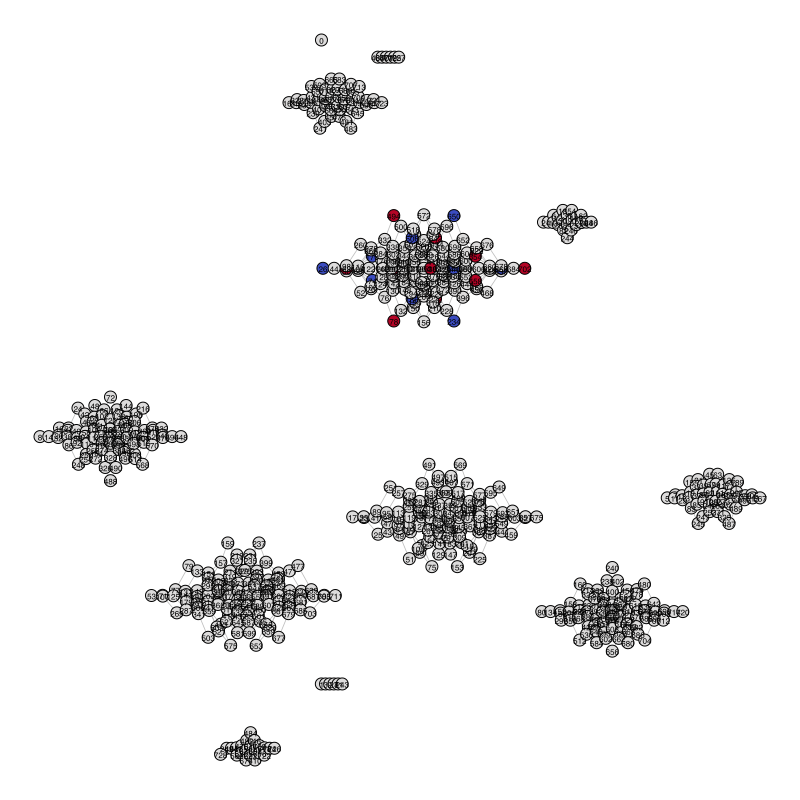

In [41]:
graph_visualizer = HamiltonianGraphVisualizer.from_sparse_matrix(
    kinetic_matrix,
    include_self_loops=False,
    style=HamiltonianGraphStyle(
        cmap="coolwarm",
        label_vertices=True,
        vertex_size=12,
    ),
)

graph_visualizer.plot(
    backend="igraph-cairo",
    color_by="state_amplitude_real",
    state_vector=record.full_state,
    layout="mds",
    title=f"Fock-space graph colored by cage-state signed amplitude",
)